In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pylab as plt
import quandl
import statsmodels.api as sm
import pandas_datareader.data as web
from statsmodels.stats.stattools import durbin_watson

In [2]:
def regress(data,yvar,xvars):
    Y = data[yvar]
    X = data[xvars]
    X['intercept'] = 1
    result = sm.OLS(Y,X).fit()
    return result.params
    

In [132]:
symbol = 'WIKI/GOOG' # or 'AAPL.US'
df =  quandl.get(symbol,start_date='2005-01-01', end_date='2010-09-05')
df

,Open,High,Low,Close,Volume,Ex-Dividend,Split Ratio,Adj. Open,Adj. High,Adj. Low,Adj. Close,Adj. Volume
Date,,,,,,,,,,,,


In [35]:
type(df)

pandas.core.frame.DataFrame

In [3]:
data1 = pd.DataFrame(data=df,columns=['Close'])
data1.columns=['GOOG']
data1

NameError: name 'df' is not defined

In [4]:
symbol = 'WIKI/AAPL' # or 'AAPL.US'
df =  quandl.get(symbol,start_date='2015-01-01', end_date='2015-09-05')
df

ForbiddenError: (Status 403) (Quandl Error QEPx04) You do not have permission to view this dataset. Please subscribe to this database to get access.

In [86]:
data2 = pd.DataFrame(data=df,columns=['Close'])
data2.columns=['AAPL']
data2

,AAPL
Date,
2015-01-02,109.33
2015-01-05,106.25
2015-01-06,106.26
2015-01-07,107.75
2015-01-08,111.89
...,...
2015-08-31,112.76
2015-09-01,107.72
2015-09-02,112.34


In [87]:
symbol = 'WIKI/MSFT' # or 'AAPL.US'
df =  quandl.get(symbol,start_date='2015-01-01', end_date='2015-09-05')
df

,Open,High,Low,Close,Volume,Ex-Dividend,Split Ratio,Adj. Open,Adj. High,Adj. Low,Adj. Close,Adj. Volume
Date,,,,,,,,,,,,
2015-01-02,46.66,47.4200,46.540,46.760,27913852.0,0.0,1.0,43.251617,43.956101,43.140383,43.344312,27913852.0
2015-01-05,46.37,46.7300,46.250,46.325,39673865.0,0.0,1.0,42.982801,43.316504,42.871566,42.941088,39673865.0
2015-01-06,46.38,46.7490,45.540,45.650,36447854.0,0.0,1.0,42.992070,43.334116,42.213430,42.315395,36447854.0
2015-01-07,45.98,46.4600,45.490,46.230,29114061.0,0.0,1.0,42.621289,43.066226,42.167082,42.853027,29114061.0
2015-01-08,46.75,47.7499,46.720,47.590,29645202.0,0.0,1.0,43.335043,44.261903,43.307234,44.113683,29645202.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2015-08-31,43.74,43.9300,43.100,43.520,34441662.0,0.0,1.0,41.368901,41.548601,40.763595,41.160827,34441662.0
2015-09-01,42.23,42.5900,41.660,41.820,49688896.0,0.0,1.0,39.940756,40.281241,39.401655,39.552982,49688896.0
2015-09-02,42.24,43.3800,41.880,43.360,37671518.0,0.0,1.0,39.950214,41.028416,39.609730,41.009500,37671518.0


In [88]:
data3 = pd.DataFrame(data=df,columns=['Close'])
data3.columns=['SPX']
data3

,SPX
Date,
2015-01-02,46.760
2015-01-05,46.325
2015-01-06,45.650
2015-01-07,46.230
2015-01-08,47.590
...,...
2015-08-31,43.520
2015-09-01,41.820
2015-09-02,43.360


In [89]:
exl = pd.concat([data1,data2,data3],axis=1)

In [90]:
exl.to_excel('exl.xlsx')
exl

,GOOG,AAPL,SPX
Date,,,
2015-01-02,109.33,109.33,46.760
2015-01-05,106.25,106.25,46.325
2015-01-06,106.26,106.26,45.650
2015-01-07,107.75,107.75,46.230
2015-01-08,111.89,111.89,47.590
...,...,...,...
2015-08-31,112.76,112.76,43.520
2015-09-01,107.72,107.72,41.820
2015-09-02,112.34,112.34,43.360


In [91]:
data = exl
ret = data.pct_change().dropna()

In [92]:
by_m = ret.groupby(lambda x:x.month)
by_m.mean()

,GOOG,AAPL,SPX
Date,,,
1,0.003927,0.003927,-0.007298
2,0.004935,0.004935,0.004356
3,-0.001357,-0.001357,-0.003358
4,0.000348,0.000348,0.008860
5,0.002102,0.002102,-0.001783
6,-0.001700,-0.001700,-0.002660
7,-0.001401,-0.001401,0.002629
8,-0.003109,-0.003109,-0.003096
9,-0.007328,-0.007328,-0.004867


In [93]:
by_m.apply(regress,'GOOG',['SPX','AAPL'])

,SPX,AAPL,intercept
Date,,,
1,-2.331468e-15,1.0,-1.387779e-17
2,-8.937295e-15,1.0,-5.377643e-17
3,-5.523360e-15,1.0,3.707971e-17
4,-6.106227e-16,1.0,-2.276825e-17
5,-2.928213e-15,1.0,-3.252607e-17
6,-1.004752e-14,1.0,-8.109832e-17
7,1.054712e-15,1.0,-2.070826e-17
8,1.165734e-15,1.0,1.066855e-16
9,4.829470e-15,1.0,3.035766e-17


In [94]:
Y = ret['GOOG']
X = ret[['SPX','AAPL']]
X['intercept'] = 1
result = sm.OLS(Y,X).fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   GOOG   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.887e+29
Date:                Tue, 26 Mar 2024   Prob (F-statistic):               0.00
Time:                        16:04:49   Log-Likelihood:                 5801.8
No. Observations:                 170   AIC:                        -1.160e+04
Df Residuals:                     167   BIC:                        -1.159e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
SPX        -2.276e-15   1.82e-15     -1.251      0.213   -5.87e-15    1.32e-15
AAPL           1.0000   1.92e-15   5.22e+14      0.000       1.000       1.000
intercept   3.534e-16   2.82e-17     12.517      0.000    2.98e-16    4.09e-16
==============================================================================
Omnibus:                       19.607   Durbin-Watson:                   0.100
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               63.996
Skew:                          -0.311   Prob(JB):                     1.27e-14
Kurtosis:                       5.941   Cond. No.                         81.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [95]:
#预测模型
xpred = [100,92,110]
ypred = result.predict(xpred)
ypred

array([92.])

In [100]:
#权重最小二乘
nsample = 50
x = np.linspace(0,20,nsample)
x = np.column_stack((x,(x - 5) ** 2)) 
x= sm.add_constant(x)
beta = [5,0.5,0.01]
sig = 0.5
w = np.ones(nsample)
w[nsample * 6 //10:] = 3
y_true = np.dot(x,beta)
e = np.random.normal(size = nsample)
y = y_true + sig * w * e
x = x[:,[0,1]]
mod = sm.OLS(y,x)
res = mod.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.909
Model:                            OLS   Adj. R-squared:                  0.907
Method:                 Least Squares   F-statistic:                     477.1
Date:                Tue, 26 Mar 2024   Prob (F-statistic):           1.39e-26
Time:                        16:18:38   Log-Likelihood:                -74.190
No. Observations:                  50   AIC:                             152.4
Df Residuals:                      48   BIC:                             156.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6999      0.303     15.488      0.000       4.090       5.310
x1             0.5711      0.026     21.842      0.000       0.519       0.624
==============================================================================
Omnibus:                        8.372   Durbin-Watson:                   2.576
Prob(Omnibus):                  0.015   Jarque-Bera (JB):                7.483
Skew:                           0.867   Prob(JB):                       0.0237
Kurtosis:                       3.763   Cond. No.                         23.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [101]:
mod_wls = sm.WLS(y,x,weights=1/w)
res_wls = mod_wls.fit()
res_wls.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.928
Model:                            WLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                     622.5
Date:                Tue, 26 Mar 2024   Prob (F-statistic):           3.90e-29
Time:                        16:20:05   Log-Likelihood:                -63.571
No. Observations:                  50   AIC:                             131.1
Df Residuals:                      48   BIC:                             135.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.7566      0.211     22.557      0.000       4.333       5.181
x1             0.5636      0.023     24.949      0.000       0.518       0.609
==============================================================================
Omnibus:                        3.255   Durbin-Watson:                   2.493
Prob(Omnibus):                  0.196   Jarque-Bera (JB):                2.943
Skew:                           0.589   Prob(JB):                        0.230
Kurtosis:                       2.838   Cond. No.                         17.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [103]:
#统计检测
#durbin_watson(resids[,axis])计算Durbin-Warningatson统计量，测试序列相关性
#jarque_bera(resids[,axis])计算Jarque-BaseExceptionera测试的正态性
#ommi_normtest(resids[,axis])计算Omnibus测试是否正态
durbin_watson(result.resid)#2完全无关，0正相关，4负相关

0.09964135418304516

In [104]:
#经验分布拟合
from statsmodels.distributions.empirical_distribution import ECDF

In [105]:
ecdf = ECDF(data['GOOG'])

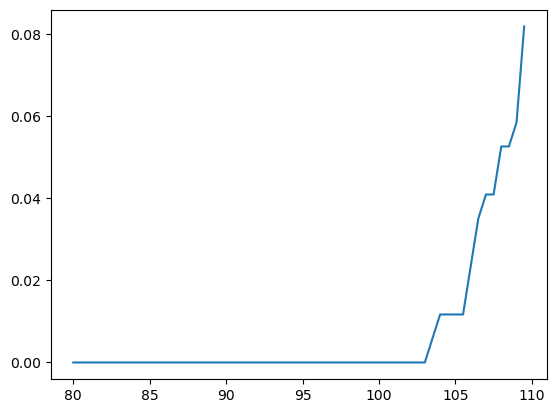

In [118]:
plt.plot(np.arange(80,110,0.5),ecdf(np.arange(80,110,0.5)))

In [119]:
#时间序列分析
from datetime import datetime
now = datetime.now()

In [120]:
now

datetime.datetime(2024, 3, 26, 16, 42, 32, 936885)

In [121]:
delta = datetime(2011,1,7) - datetime(2008,6,24,8,15)

In [122]:
delta

datetime.timedelta(days=926, seconds=56700)

In [124]:
stamp = datetime(2011,1,3)
str(stamp)

'2011-01-03 00:00:00'

In [125]:
stamp.strftime('%y-%m-%d')

'11-01-03'

In [126]:
datestrs = ['2011-07-06','2011-08-06','2011-08-09']
pd.to_datetime(datestrs)

DatetimeIndex(['2011-07-06', '2011-08-06', '2011-08-09'], dtype='datetime64[ns]', freq=None)

In [132]:
frame = pd.DataFrame(np.random.randn(2,4),index=pd.date_range('1/1/2000',periods=2,freq='W-WED'),columns = ['Colorado','Texas','New York','Ohio'])
frame

,Colorado,Texas,New York,Ohio
2000-01-05,-0.707611,0.346277,-0.321726,0.235213
2000-01-12,1.106928,0.862677,0.424228,-1.097650


In [133]:
df_daily = frame.resample('D').asfreq()
df_daily

,Colorado,Texas,New York,Ohio
2000-01-05,-0.707611,0.346277,-0.321726,0.235213
2000-01-06,NaN,NaN,NaN,NaN
2000-01-07,NaN,NaN,NaN,NaN
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,1.106928,0.862677,0.424228,-1.097650


In [134]:
frame.resample('D').ffill()

,Colorado,Texas,New York,Ohio
2000-01-05,-0.707611,0.346277,-0.321726,0.235213
2000-01-06,-0.707611,0.346277,-0.321726,0.235213
2000-01-07,-0.707611,0.346277,-0.321726,0.235213
2000-01-08,-0.707611,0.346277,-0.321726,0.235213
2000-01-09,-0.707611,0.346277,-0.321726,0.235213
2000-01-10,-0.707611,0.346277,-0.321726,0.235213
2000-01-11,-0.707611,0.346277,-0.321726,0.235213
2000-01-12,1.106928,0.862677,0.424228,-1.097650


In [136]:
frame = pd.DataFrame(np.random.randn(2,4),index=pd.date_range('1/1/2000',periods=2,freq='YE'),columns = ['Colorado','Texas','New York','Ohio'])
frame

,Colorado,Texas,New York,Ohio
2000-12-31,1.823909,0.181524,-0.435567,-0.224019
2001-12-31,1.362484,0.447395,0.338823,-1.615936


In [140]:
frame.resample('QE-DEC').ffill()

,Colorado,Texas,New York,Ohio
2000-12-31,1.823909,0.181524,-0.435567,-0.224019
2001-03-31,1.823909,0.181524,-0.435567,-0.224019
2001-06-30,1.823909,0.181524,-0.435567,-0.224019
2001-09-30,1.823909,0.181524,-0.435567,-0.224019
2001-12-31,1.362484,0.447395,0.338823,-1.615936


In [143]:
symbol = 'WIKI/AAPL' # or 'AAPL.US'
df =  quandl.get(symbol,start_date='2015-01-01', end_date='2017-09-05')
df = df.sort_index()

In [144]:
df.head()
df

,Open,High,Low,Close,Volume,Ex-Dividend,Split Ratio,Adj. Open,Adj. High,Adj. Low,Adj. Close,Adj. Volume
Date,,,,,,,,,,,,
2015-01-02,111.39,111.44,107.350,109.33,53204626.0,0.0,1.0,105.820966,105.868466,101.982949,103.863957,53204626.0
2015-01-05,108.29,108.65,105.410,106.25,64285491.0,0.0,1.0,102.875953,103.217954,100.139941,100.937944,64285491.0
2015-01-06,106.54,107.43,104.630,106.26,65797116.0,0.0,1.0,101.213446,102.058949,99.398938,100.947444,65797116.0
2015-01-07,107.20,108.20,106.695,107.75,40105934.0,0.0,1.0,101.840448,102.790453,101.360696,102.362951,40105934.0
2015-01-08,109.23,112.15,108.700,111.89,59364547.0,0.0,1.0,103.768957,106.542969,103.265455,106.295968,59364547.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2017-08-29,160.10,163.12,160.000,162.91,29307862.0,0.0,1.0,160.100000,163.120000,160.000000,162.910000,29307862.0
2017-08-30,163.80,163.89,162.610,163.35,26973946.0,0.0,1.0,163.800000,163.890000,162.610000,163.350000,26973946.0
2017-08-31,163.64,164.52,163.480,164.00,26412439.0,0.0,1.0,163.640000,164.520000,163.480000,164.000000,26412439.0


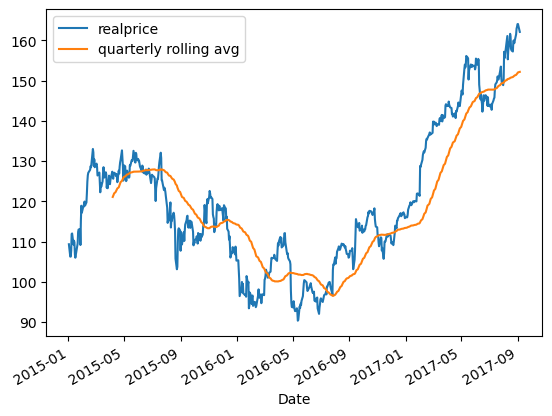

In [149]:
df['Close'].plot()
df['Close'].rolling(65).mean().plot()
plt.legend(['realprice','quarterly rolling avg'])

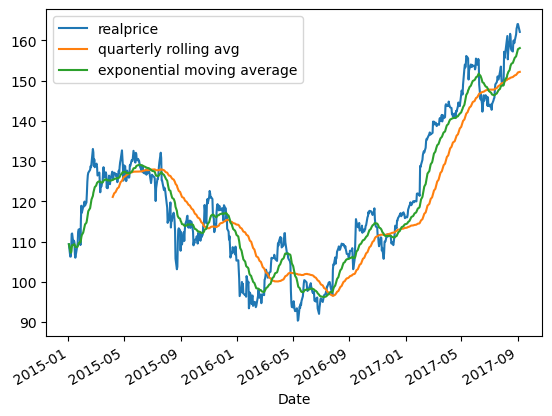

In [154]:
df['Close'].plot()
df['Close'].rolling(65).mean().plot()
df['Close'].ewm(span=30).mean().plot()
plt.legend(['realprice','quarterly rolling avg','exponential moving average'])

<Axes: xlabel='Date'>

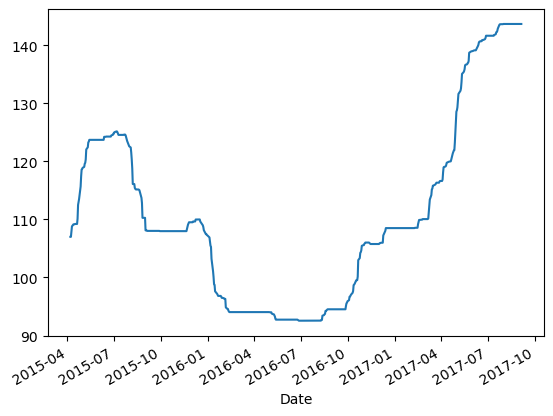

In [155]:
df['Close'].rolling(65).apply(lambda x:np.percentile(x,5)).plot()

In [10]:
#ARMA模型
import random
values =[4,4]
N = 1000
b0 = 0.4
b1 = -0.4
noise = np.random.normal(0,0.1,N)
for i in range(N):
    new_x = values[-1] * b0 + values[-2] *b1 + noise[i]#AR(2)
    values.append(new_x)

In [11]:
import statsmodels.api as sm

MAXLAGS = 5
model = sm.tsa.AutoReg(values, lags=MAXLAGS)
results = model.fit()
results.params

array([-0.00064204,  0.3572374 , -0.34136553, -0.05087297,  0.05632203,
       -0.02327401])

In [12]:
MAXLAGS = 2
model = sm.tsa.AutoReg(values, lags=MAXLAGS)
results = model.fit()
results.params

array([-0.00066101,  0.36856792, -0.3827012 ])

In [13]:
#自相关函数
from statsmodels.graphics.tsaplots import plot_acf

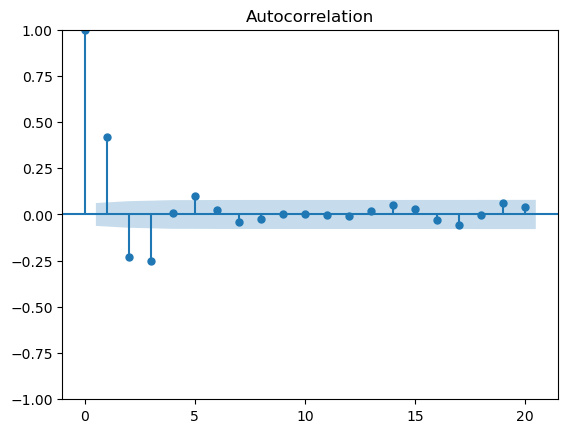

In [14]:
acf = plot_acf(values,lags=20)

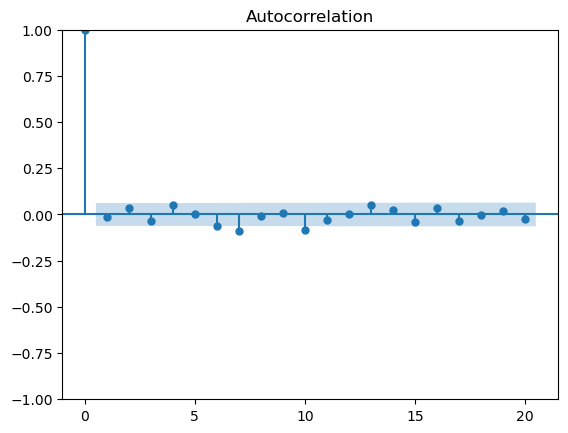

In [15]:
acf = plot_acf(results.resid,lags=20)

In [17]:
#statsmodels.tsa.arima_process.ArmaProcess(ar,ma,nobs = 100)#创建
#参数
#ar:array_like,1d 自回归滞后多项式系数包括零滞后
#ma:array_like,1d 移动平均滞后多项式的系数，包括零滞后
#nobs:int ,可选 模拟时间序列的长度

In [18]:
#时间序列检验
#statsmodels.acovf(x[,unbiased,demean,fft,...])一维自协方差
#statsmodels.acf(x[,unbiased,nlags,qstat,....])一维数组自相关函数
#statsmodels.pacf(x[,nlags,method,alpha])估计部分自相关
#......

In [19]:
#Scipy(数据分别，最优化，插值，解方程)

In [20]:
#插值
import scipy.interpolate as spi

In [21]:
x = np.linspace(-2*np.pi,2*np.pi,25)

In [22]:
def f(x):
    return np.sin(x) + 0.5 * x

In [23]:
ipo = spi.splrep(x,f(x),k = 1)#linear
iy = spi.splev(x,ipo)

Text(0, 0.5, 'f(x)')

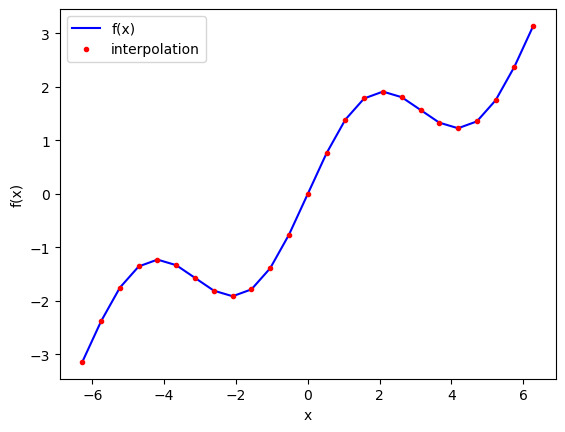

In [24]:
plt.plot(x,f(x),'b',label='f(x)')
plt.plot(x,iy,'r.',label = 'interpolation')
plt.legend(loc=0)
plt.xlabel('x')
plt.ylabel('f(x)')

Text(0, 0.5, 'f(x)')

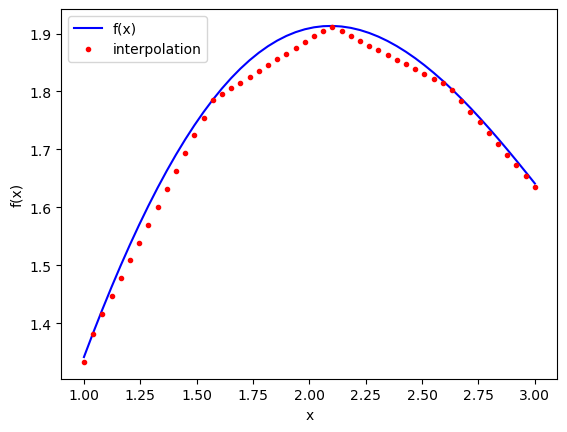

In [25]:
xd = np.linspace(1,3,50)
iyd = spi.splev(xd,ipo)
plt.plot(xd,f(xd),'b',label='f(x)')
plt.plot(xd,iyd,'r.',label = 'interpolation')
plt.legend(loc=0)
plt.xlabel('x')
plt.ylabel('f(x)')

Text(0, 0.5, 'f(x)')

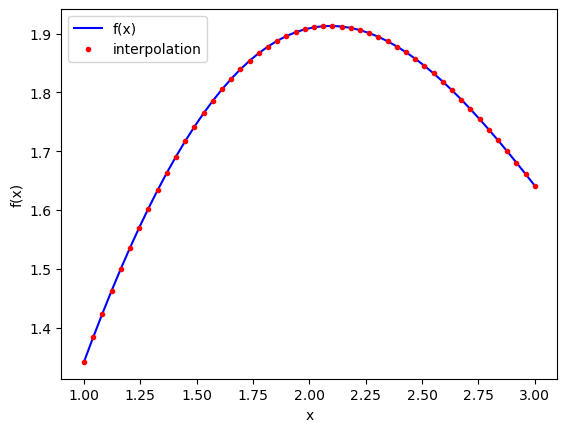

In [26]:
ipo = spi.splrep(x,f(x),k = 3)
iyd = spi.splev(xd,ipo)
plt.plot(xd,f(xd),'b',label='f(x)')
plt.plot(xd,iyd,'r.',label = 'interpolation')
plt.legend(loc=0)
plt.xlabel('x')
plt.ylabel('f(x)')

In [71]:
#凸优化
import scipy.optimize as spo
def fo(xy):
    x, y = xy
    z = np.sin(x) + 0.05 * x**2 + np.sin(y) + 0.05 * y**2
    if output==True:
        print('%8.4f, %8.4f, %8.4f' % (x, y, z))
    return z

In [72]:
output = True
spo.brute(fo,((-10, 10.1, 5),(-10, 10.1, 5)),finish=None)

-10.0000, -10.0000,  11.0880
-10.0000,  -5.0000,   7.7529
-10.0000,   0.0000,   5.5440
-10.0000,   5.0000,   5.8351
-10.0000,  10.0000,  10.0000
 -5.0000, -10.0000,   7.7529
 -5.0000,  -5.0000,   4.4178
 -5.0000,   0.0000,   2.2089
 -5.0000,   5.0000,   2.5000
 -5.0000,  10.0000,   6.6649
  0.0000, -10.0000,   5.5440
  0.0000,  -5.0000,   2.2089
  0.0000,   0.0000,   0.0000
  0.0000,   5.0000,   0.2911
  0.0000,  10.0000,   4.4560
  5.0000, -10.0000,   5.8351
  5.0000,  -5.0000,   2.5000
  5.0000,   0.0000,   0.2911
  5.0000,   5.0000,   0.5822
  5.0000,  10.0000,   4.7471
 10.0000, -10.0000,  10.0000
 10.0000,  -5.0000,   6.6649
 10.0000,   0.0000,   4.4560
 10.0000,   5.0000,   4.7471
 10.0000,  10.0000,   8.9120


array([0., 0.])

In [76]:
output = False
opt1 = spo.brute(fo,((-10, 10.1, 0.1),(-10, 10.1, 0.1)),finish=None)
opt1

array([-1.4, -1.4])

In [77]:
output = True
opt2 = spo.fmin(fo,opt1,xtol=0.001,ftol=0.001,maxiter=15,maxfun=20)
opt2

 -1.4000,  -1.4000,  -1.7749
 -1.4700,  -1.4000,  -1.7743
 -1.4000,  -1.4700,  -1.7743
 -1.3300,  -1.4700,  -1.7696
 -1.4350,  -1.4175,  -1.7756
 -1.4350,  -1.3475,  -1.7722
 -1.4088,  -1.4394,  -1.7755
 -1.4438,  -1.4569,  -1.7751
 -1.4328,  -1.4427,  -1.7756
 -1.4591,  -1.4208,  -1.7752
 -1.4213,  -1.4347,  -1.7757
 -1.4235,  -1.4096,  -1.7755
 -1.4305,  -1.4344,  -1.7757
 -1.4168,  -1.4516,  -1.7753
 -1.4305,  -1.4260,  -1.7757
 -1.4396,  -1.4257,  -1.7756
 -1.4259,  -1.4325,  -1.7757
 -1.4259,  -1.4241,  -1.7757
 -1.4304,  -1.4177,  -1.7757
 -1.4270,  -1.4288,  -1.7757


C:\Users\86157\AppData\Local\Temp\ipykernel_42876\1159651932.py:2: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  opt2 = spo.fmin(fo,opt1,xtol=0.001,ftol=0.001,maxiter=15,maxfun=20)


array([-1.42702972, -1.42876755])

In [78]:
output = False
spo.fmin(fo,(2.0,2.0),maxiter=250)

Optimization terminated successfully.
         Current function value: 0.015826
         Iterations: 46
         Function evaluations: 86


array([4.2710728 , 4.27106945])

In [109]:
from math import sqrt
import scipy.optimize as spo

# 目标函数
def Eu(x):
    s, b = x
    return 0.5 * sqrt(s * 15 + b * 5) + 0.5 * sqrt(s * 5 + b * 12)

# 约束条件函数
def constraint_function(x):
    return 100 - x[0] * 10 - x[1] * 10

# 约束条件
cons = ({'type': 'ineq', 'fun': constraint_function})

# 上下限
bnds = ((0, 1000), (0, 1000))

# 最小化目标函数，考虑约束条件和变量的上下限
result = spo.minimize(Eu, [5, 5], method='SLSQP', bounds=bnds, constraints=cons)
print(result)

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 1.1847525731723186e-06
       x: [ 8.438e-14  6.661e-14]
     nit: 8
     jac: [ 2.494e+04  2.327e+04]
    nfev: 12
    njev: 4


In [110]:
#积分
import scipy.integrate as sci
def f(x):
    return np.sin(x) + x**2

In [114]:
a = 0.5#积分上限
b = 9.5#积分下限
x=np.linspace(0,10)
y = f(x)
x

array([ 0.        ,  0.20408163,  0.40816327,  0.6122449 ,  0.81632653,
        1.02040816,  1.2244898 ,  1.42857143,  1.63265306,  1.83673469,
        2.04081633,  2.24489796,  2.44897959,  2.65306122,  2.85714286,
        3.06122449,  3.26530612,  3.46938776,  3.67346939,  3.87755102,
        4.08163265,  4.28571429,  4.48979592,  4.69387755,  4.89795918,
        5.10204082,  5.30612245,  5.51020408,  5.71428571,  5.91836735,
        6.12244898,  6.32653061,  6.53061224,  6.73469388,  6.93877551,
        7.14285714,  7.34693878,  7.55102041,  7.75510204,  7.95918367,
        8.16326531,  8.36734694,  8.57142857,  8.7755102 ,  8.97959184,
        9.18367347,  9.3877551 ,  9.59183673,  9.79591837, 10.        ])

In [115]:
sci.fixed_quad(f,a,b)[0]

287.6169959670845

In [116]:
sci.quad(f,a,b)[0]

287.62475471808676

In [118]:
sci.romberg(f,a,b)

C:\Users\86157\AppData\Local\Temp\ipykernel_42876\1167914472.py:1: DeprecationWarning: `scipy.integrate.romberg` is deprecated as of SciPy 1.12.0and will be removed in SciPy 1.15.0. Please use`scipy.integrate.quad` instead.
  sci.romberg(f,a,b)


287.62475471839196

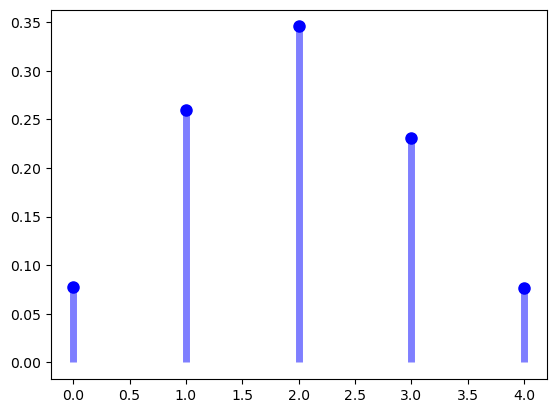

In [121]:
#分布
from scipy.stats import binom
fig,ax = plt.subplots(1,1)
n,p = 5,0.4
x = np.arange(binom.ppf(0.01,n,p),binom.ppf(0.99,n,p))
ax.plot(x,binom.pmf(x,n,p),'bo',ms=8,label='binom pmf')
ax.vlines(x,0,binom.pmf(x,n,p),colors = 'b',lw=5,alpha=0.5)

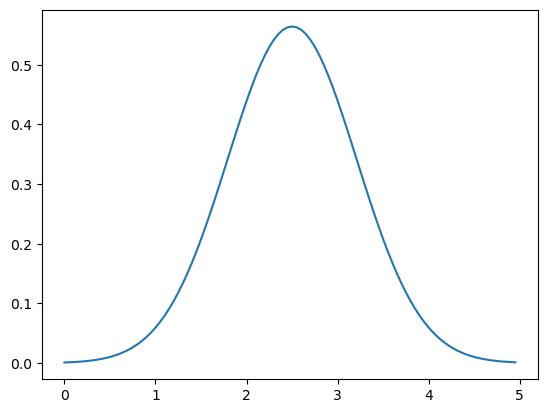

In [124]:
from scipy.stats import multivariate_normal
x = np.linspace(0,5,100,endpoint=False)
y = multivariate_normal.pdf(x,mean=2.5,cov=0.5)
fig1 = plt.figure()
ax = fig1.add_subplot(111)
ax.plot(x,y)